Importing dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

Data Import and Profiling

In [81]:
exercise = pd.read_csv("exercise.csv")
calories = pd.read_csv("calories.csv")
#exercise.info()
#calories.info()
df = pd.merge(exercise, calories, on = "User_ID")
print(df.shape)

(15000, 9)


In [82]:
df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)
df['Gender_Encoded'] = df['Gender'].map({'male': 1, 'female': 0})

In [86]:
num_columns = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories', 'BMI', 'Gender_Encoded']
non_num_rows = []
for col in num_columns:
    if col not in df.select_dtypes(include = 'number').columns:
        non_num_rows.append(col)
print(non_num_rows)
print(df['Gender'].unique())
print(df.isnull().sum())
print(df['User_ID'].duplicated().sum())
print(df[num_columns].describe(include = 'all'))

[]
<StringArray>
['male', 'female']
Length: 2, dtype: str
User_ID           0
Gender            0
Age               0
Height            0
Weight            0
Duration          0
Heart_Rate        0
Body_Temp         0
Calories          0
BMI               0
Gender_Encoded    0
dtype: int64
0
                Age        Height        Weight      Duration    Heart_Rate  \
count  15000.000000  15000.000000  15000.000000  15000.000000  15000.000000   
mean      42.789800    174.465133     74.966867     15.530600     95.518533   
std       16.980264     14.258114     15.035657      8.319203      9.583328   
min       20.000000    123.000000     36.000000      1.000000     67.000000   
25%       28.000000    164.000000     63.000000      8.000000     88.000000   
50%       39.000000    175.000000     74.000000     16.000000     96.000000   
75%       56.000000    185.000000     87.000000     23.000000    103.000000   
max       79.000000    222.000000    132.000000     30.000000    128.000000

Exploratory Data Analysis

Text(0.5, 1.0, 'Calories Distribution')

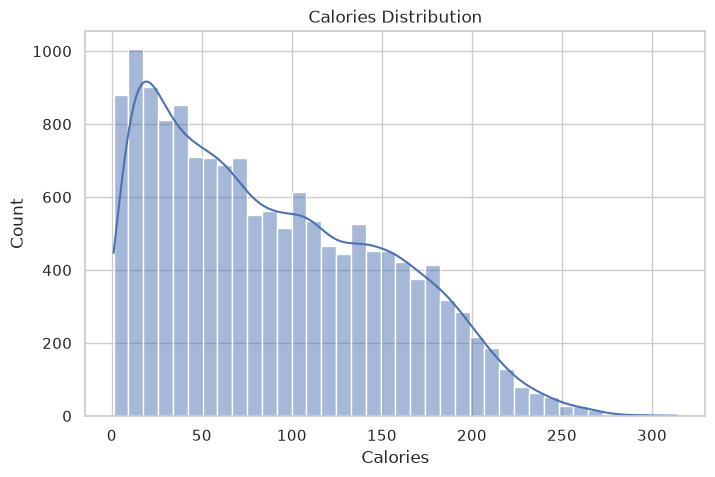

In [98]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Calories'], kde = True).set_title('Calories Distribution')

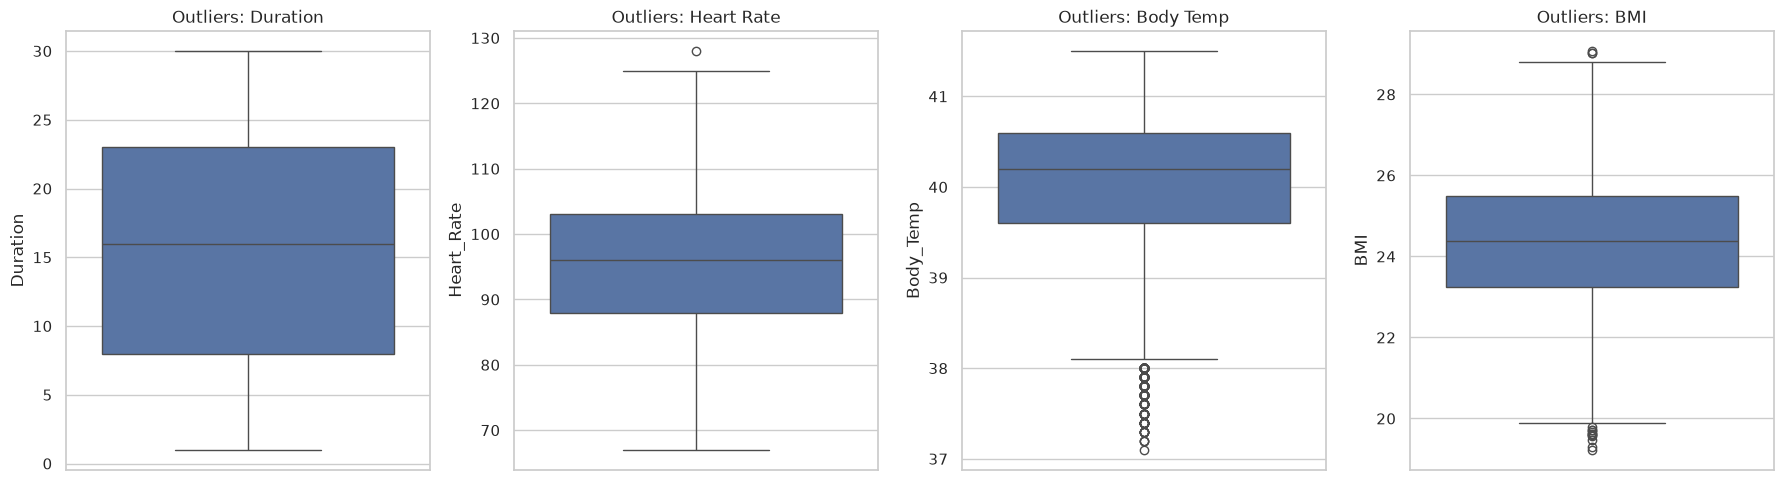

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
sns.boxplot(y=df['Duration'], ax=axes[0]).set_title('Outliers: Duration')
sns.boxplot(y=df['Heart_Rate'], ax=axes[1]).set_title('Outliers: Heart Rate')
sns.boxplot(y=df['Body_Temp'], ax=axes[2]).set_title('Outliers: Body Temp')
sns.boxplot(y=df['BMI'], ax=axes[3]).set_title('Outliers: BMI')
plt.tight_layout()
plt.show()

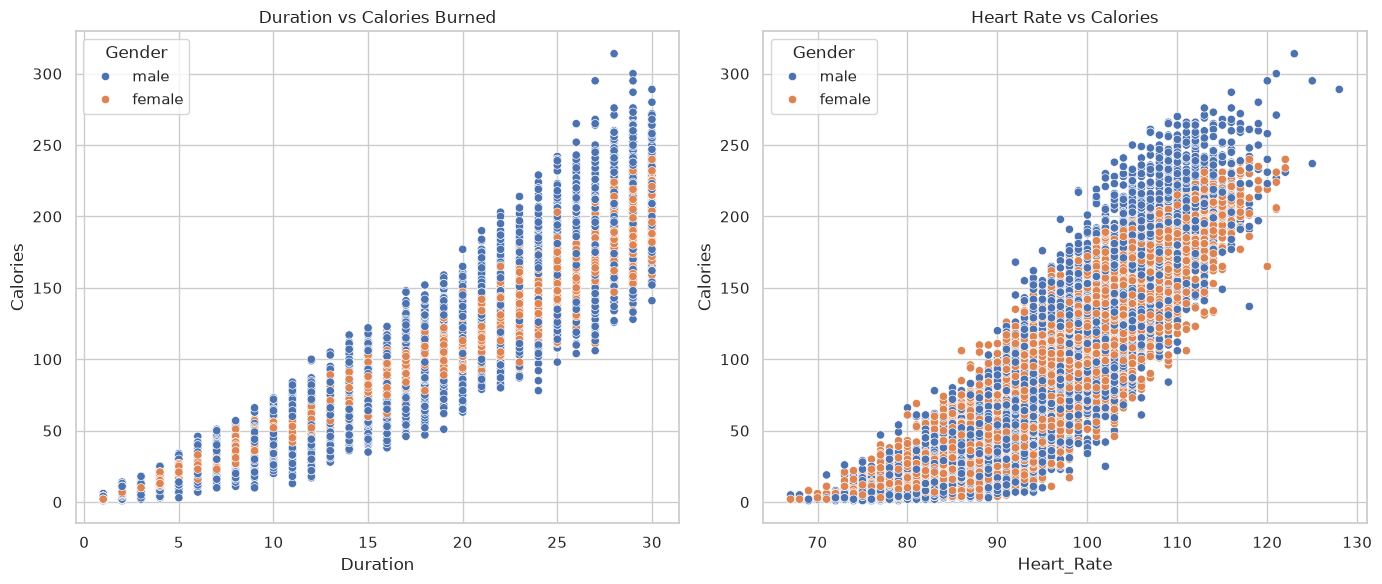

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=df, x='Duration', y='Calories', hue='Gender', ax=axes[0])
axes[0].set_title('Duration vs Calories Burned')
sns.scatterplot(data=df, x='Heart_Rate', y='Calories', hue='Gender', ax=axes[1])
axes[1].set_title('Heart Rate vs Calories')
plt.tight_layout()
plt.show()

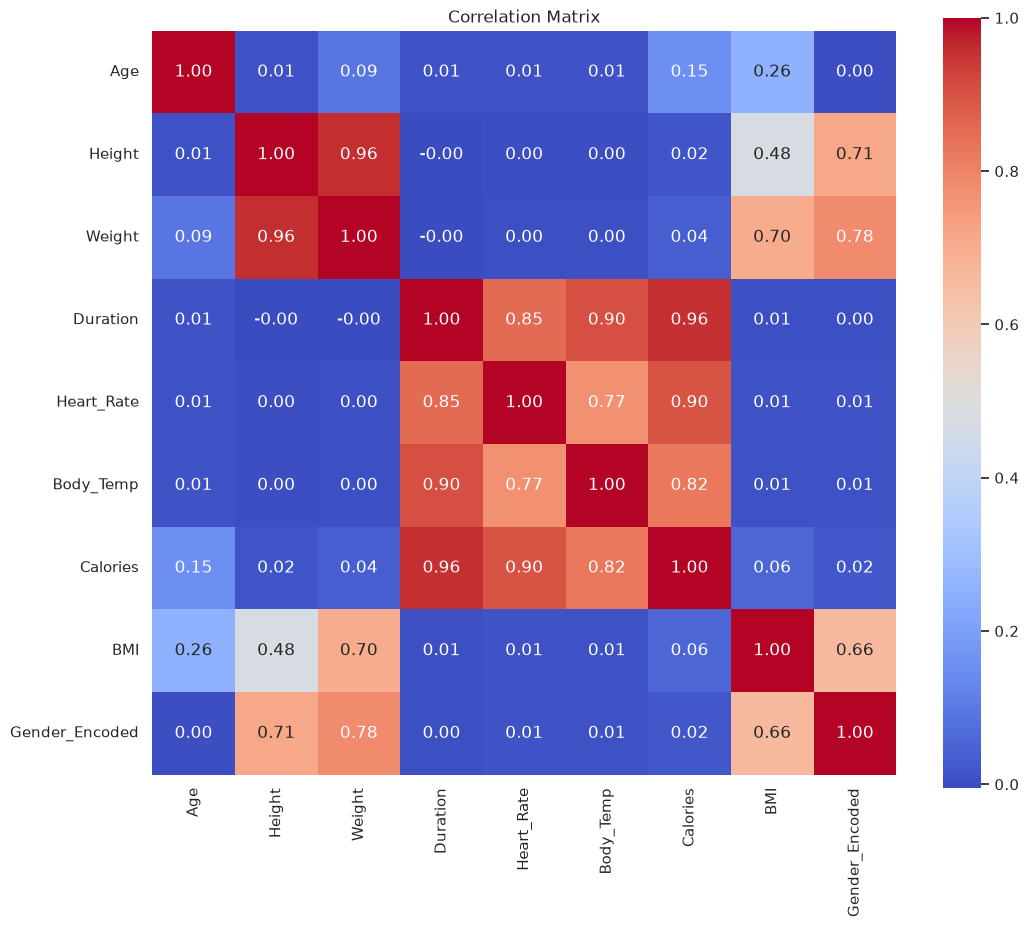

In [108]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[num_columns].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

Data Preparation

In [118]:
calories_skew = df['Calories'].skew()
duration_skew = df['Duration'].skew()

print(f"Calories Skewness: {calories_skew:.2f}")
print(f"Duration Skewness: {duration_skew:.2f}")

def outliers(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    dataframe[column] = np.where(dataframe[column] < lower_bound, lower_bound, dataframe[column])
    dataframe[column] = np.where(dataframe[column] > upper_bound, upper_bound, dataframe[column])
    return dataframe

columns_with_outliers = ['Heart_Rate', 'Body_Temp', 'BMI']

for col in columns_with_outliers:
    df = outliers(df, col)

Calories Skewness: 0.51
Duration Skewness: 0.00


In [130]:
df_num = df.drop(columns=['Calories', 'Gender'])
normalized_df = (df_num - df_num.mean()) / df_num.std()
normalized_df['Calories'] = df['Calories'].values
normalized_df.head()
summary_check = pd.DataFrame({'Mean': normalized_df.drop(columns=['Calories']).mean(), 'Std': normalized_df.drop(columns=['Calories']).std()})
print(summary_check)


                        Mean  Std
User_ID         2.688220e-16  1.0
Age             3.457975e-17  1.0
Height         -5.469995e-16  1.0
Weight          3.777719e-16  1.0
Duration        4.606685e-17  1.0
Heart_Rate      1.430559e-16  1.0
Body_Temp       2.487847e-15  1.0
BMI            -6.361726e-16  1.0
Gender_Encoded  8.289665e-17  1.0
